# Stock Market Analysis

In this notebook I am analyzing historical stock market data to identify trends and patterns in prices over time. The dataset contains daily price data (Open, High, Low, Close, Adjusted Close, and Volume) for several major stock market indices. I will focus on one index, clean the data, and then look at moving averages and trading volume to understand how it has performed over time.

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

## 2. Loading the Dataset

In [2]:
df = pd.read_csv('Market.csv')
df.head()

,Index,Date,Open,High,Low,Close,Adj Close,Volume
0,NYA,12/31/1965,528.690002,528.690002,528.690002,528.690002,528.690002,0.0
1,NYA,1/3/1966,527.210022,527.210022,527.210022,527.210022,527.210022,0.0
2,NYA,1/4/1966,527.840027,527.840027,527.840027,527.840027,527.840027,0.0
3,NYA,1/5/1966,531.119995,531.119995,531.119995,531.119995,531.119995,0.0
4,NYA,1/6/1966,532.070007,532.070007,532.070007,532.070007,532.070007,0.0


## 3. Basic Exploration

In [3]:
df.shape

(112457, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112457 entries, 0 to 112456
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Index      112457 non-null  str    
 1   Date       112457 non-null  str    
 2   Open       110253 non-null  float64
 3   High       110252 non-null  float64
 4   Low        110251 non-null  float64
 5   Close      110250 non-null  float64
 6   Adj Close  110244 non-null  float64
 7   Volume     110253 non-null  float64
dtypes: float64(6), str(2)
memory usage: 6.9 MB


In [5]:
df['Index'].value_counts()

Index
N225         14500
NYA          13948
IXIC         12690
GSPTSE       10776
HSI           8750
GDAXI         8606
SSMI          7830
KS11          6181
TWII          6010
000001.SS     5963
399001.SZ     5928
N100          5507
NSEI          3381
J203.JO       2387
Name: count, dtype: int64

The dataset has data for multiple stock indices combined together. Since each one trades on a different schedule, I am going to focus on a single index for this analysis, the NYSE Composite (NYA), which has one of the longest histories in the data.

## 4. Filtering for One Index

In [6]:
nya = df[df['Index'] == 'NYA'].copy()
nya.shape

(13948, 8)

In [7]:
nya.isnull().sum()

Index         0
Date          0
Open          1
High          2
Low           3
Close         4
Adj Close    10
Volume        1
dtype: int64

## 5. Data Cleaning

In [8]:
nya['Date'] = pd.to_datetime(nya['Date'])
nya.sort_values('Date', inplace=True)
nya.reset_index(drop=True, inplace=True)
nya.head()

,Index,Date,Open,High,Low,Close,Adj Close,Volume
0,NYA,1965-12-31,528.690002,528.690002,528.690002,528.690002,528.690002,0.0
1,NYA,1966-01-03,527.210022,527.210022,527.210022,527.210022,527.210022,0.0
2,NYA,1966-01-04,527.840027,527.840027,527.840027,527.840027,527.840027,0.0
3,NYA,1966-01-05,531.119995,531.119995,531.119995,531.119995,531.119995,0.0
4,NYA,1966-01-06,532.070007,532.070007,532.070007,532.070007,532.070007,0.0


In [9]:
nya.dropna(inplace=True)
nya.isnull().sum()

Index        0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [10]:
nya.duplicated().sum()

np.int64(0)

## 6. Daily Price Change

I calculated the daily percentage change in the closing price, and then used a `match` statement to label each day as a Gain, Loss, or Flat day depending on that change.

In [11]:
nya['Daily_Return'] = nya['Close'].pct_change() * 100
nya.dropna(inplace=True)

def day_label(change):
    match change:
        case c if c > 0:
            return 'Gain'
        case c if c < 0:
            return 'Loss'
        case _:
            return 'Flat'

nya['Day_Type'] = nya['Daily_Return'].apply(day_label)
nya[['Date', 'Close', 'Daily_Return', 'Day_Type']].head(10)

,Date,Close,Daily_Return,Day_Type
1,1966-01-03,527.210022,-0.279933,Loss
2,1966-01-04,527.840027,0.119498,Gain
3,1966-01-05,531.119995,0.621394,Gain
4,1966-01-06,532.070007,0.178870,Gain
5,1966-01-07,532.599976,0.099605,Gain
6,1966-01-10,533.869995,0.238456,Gain
7,1966-01-11,534.289978,0.078668,Gain
8,1966-01-12,533.340027,-0.177797,Loss
9,1966-01-13,534.400024,0.198747,Gain
10,1966-01-14,535.450012,0.196480,Gain


In [12]:
nya['Day_Type'].value_counts()

Day_Type
Gain    7362
Loss    6500
Flat      69
Name: count, dtype: int64

## 7. Moving Averages

I added a 50-day and 200-day moving average of the closing price. These are commonly used to smooth out short-term noise and reveal the overall trend.

In [13]:
nya['MA_50'] = nya['Close'].rolling(window=50).mean()
nya['MA_200'] = nya['Close'].rolling(window=200).mean()
nya[['Date', 'Close', 'MA_50', 'MA_200']].tail(10)

,Date,Close,MA_50,MA_200
13938,2021-05-17,16422.96094,15943.984355,14350.934649
13939,2021-05-18,16337.73047,15964.971367,14370.298052
13940,2021-05-19,16233.32031,15982.125176,14388.780606
13941,2021-05-20,16350.45020,15998.697383,14407.472305
13942,2021-05-21,16375.00000,16013.237383,14425.689556
13943,2021-05-24,16464.68945,16028.226973,14444.367153
13944,2021-05-25,16390.18945,16040.520762,14462.488901
13945,2021-05-26,16451.96094,16056.173984,14480.528608
13946,2021-05-27,16531.94922,16072.189961,14498.941206
13947,2021-05-28,16555.66016,16091.521367,14516.845356


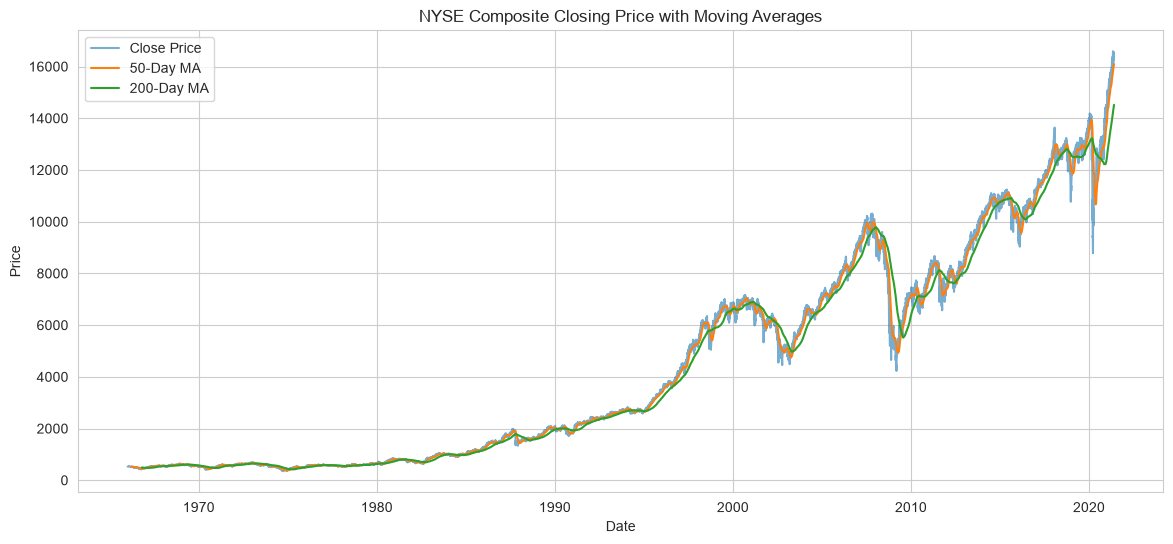

In [14]:
plt.figure(figsize=(14,6))
plt.plot(nya['Date'], nya['Close'], label='Close Price', alpha=0.6)
plt.plot(nya['Date'], nya['MA_50'], label='50-Day MA')
plt.plot(nya['Date'], nya['MA_200'], label='200-Day MA')
plt.title('NYSE Composite Closing Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

## 8. Trading Volume Over Time

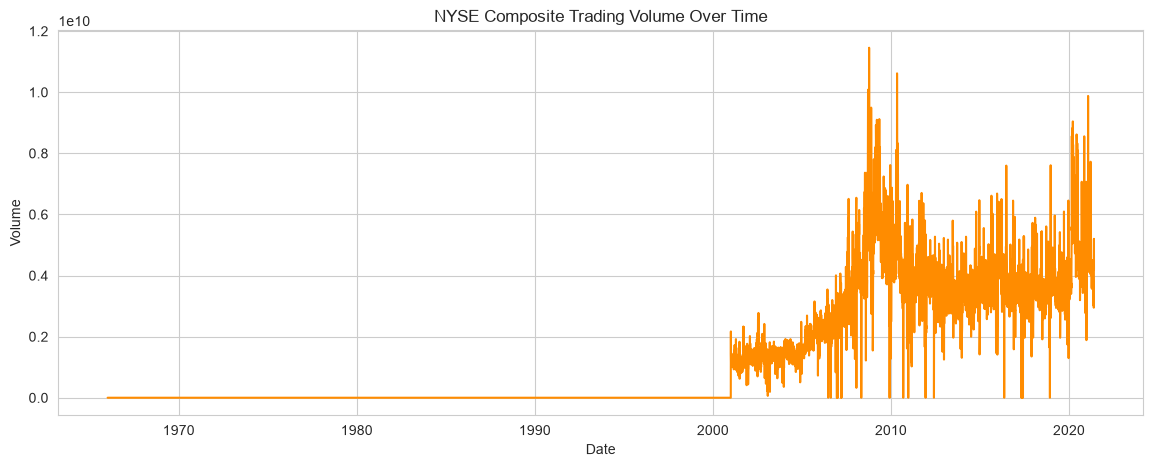

In [15]:
plt.figure(figsize=(14,5))
plt.plot(nya['Date'], nya['Volume'], color='darkorange')
plt.title('NYSE Composite Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

## 9. Distribution of Daily Returns

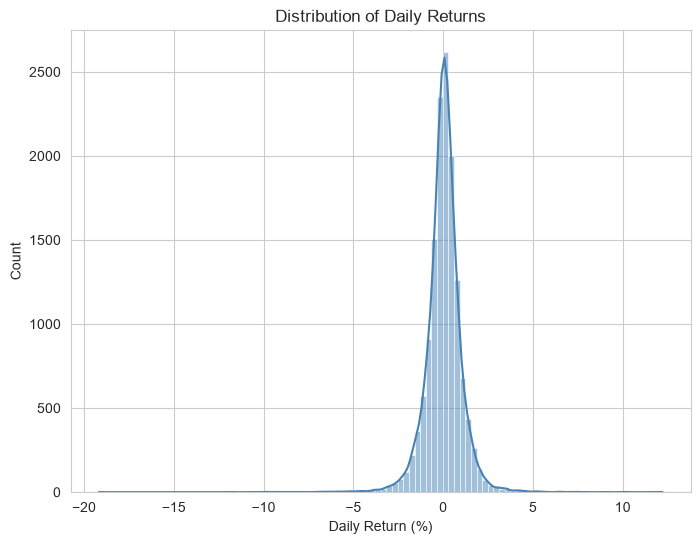

In [16]:
plt.figure(figsize=(8,6))
sns.histplot(nya['Daily_Return'], bins=100, kde=True, color='steelblue')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return (%)')
plt.show()

## 10. Rolling Volatility

I calculated a 30-day rolling standard deviation of the daily returns to see how volatile the market has been over time.

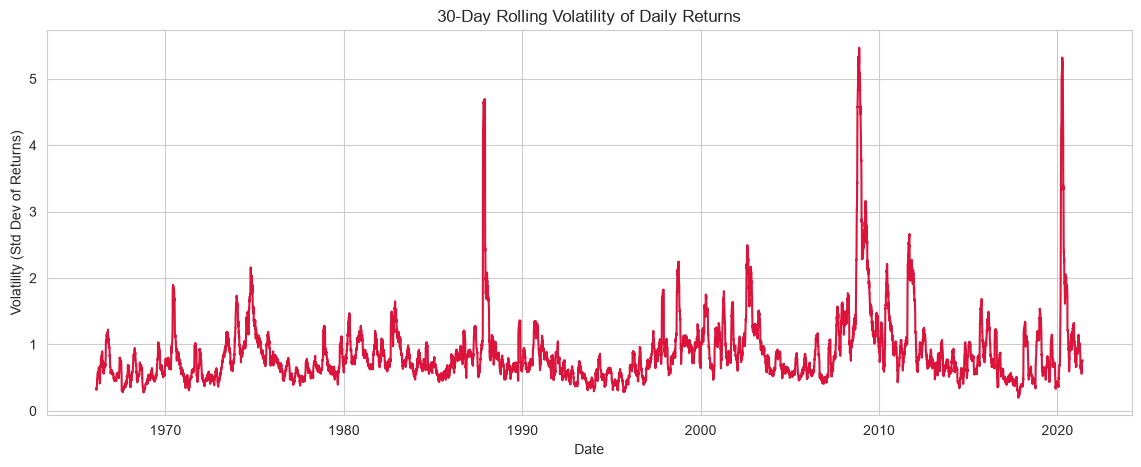

In [17]:
nya['Volatility_30'] = nya['Daily_Return'].rolling(window=30).std()

plt.figure(figsize=(14,5))
plt.plot(nya['Date'], nya['Volatility_30'], color='crimson')
plt.title('30-Day Rolling Volatility of Daily Returns')
plt.xlabel('Date')
plt.ylabel('Volatility (Std Dev of Returns)')
plt.show()

## 11. Yearly Average Closing Price

In [18]:
nya['Year'] = nya['Date'].dt.year
yearly_avg = nya.groupby('Year')['Close'].mean()
yearly_avg.tail(10)

Year
2012     8008.235865
2013     9432.335007
2014    10655.293012
2015    10673.225013
2016    10391.711566
2017    11846.116877
2018    12653.069123
2019    12864.524546
2020    12624.352894
2021    15601.780551
Name: Close, dtype: float64

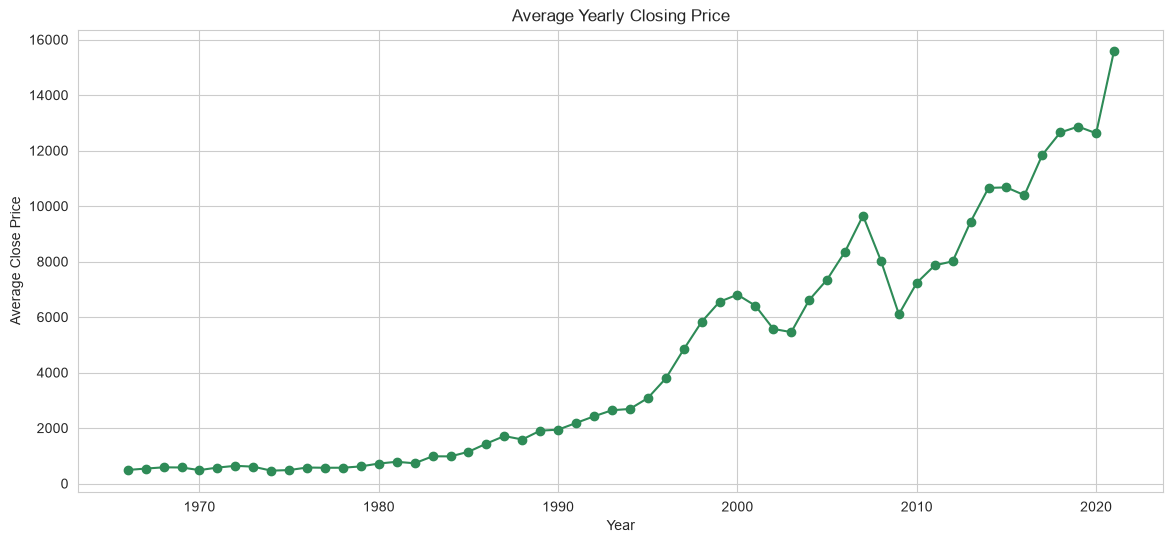

In [19]:
plt.figure(figsize=(14,6))
yearly_avg.plot(kind='line', marker='o', color='seagreen')
plt.title('Average Yearly Closing Price')
plt.xlabel('Year')
plt.ylabel('Average Close Price')
plt.show()

## 12. Correlation Between Price and Volume

In [20]:
corr_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return']
corr = nya[corr_cols].corr()
corr

,Open,High,Low,Close,Volume,Daily_Return
Open,1.000000,0.999777,0.999880,0.999854,0.801034,0.000441
High,0.999777,1.000000,0.999783,0.999820,0.803270,0.003888
Low,0.999880,0.999783,1.000000,0.999957,0.797935,0.005219
Close,0.999854,0.999820,0.999957,1.000000,0.800679,0.008568
Volume,0.801034,0.803270,0.797935,0.800679,1.000000,-0.013831
Daily_Return,0.000441,0.003888,0.005219,0.008568,-0.013831,1.000000


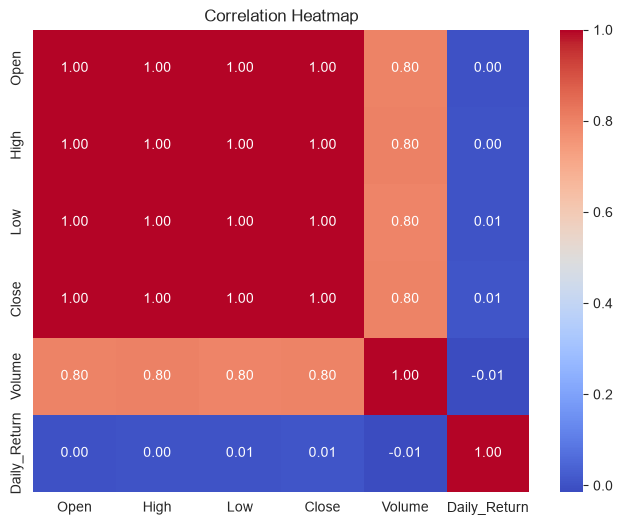

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## 13. Conclusion

Looking at the NYSE Composite index over its full history, the long-term trend is clearly upward, and the 50-day and 200-day moving averages help smooth out the day-to-day noise to show that trend more clearly. Periods where the 50-day average crosses below the 200-day average tend to line up with market downturns, which matches what these indicators are usually used for. The rolling volatility plot also shows clear spikes during major market events, and daily returns are heavily concentrated around zero with a roughly symmetric distribution, which is typical for market index data. Price and volume don't show a very strong direct correlation, since volume tends to spike independently of the direction of the price movement.